# Project Summary

Our project focuses on identifying crucial intervention points for reducing greenhouse gas emissions in food production and waste management across four East Asian countries: China, Japan, Republic of Korea, and Mongolia. We specifically examined the change in emissions from 2000 to 2020, revealing a significant increase, with China identified as a high-emission zone. A detailed examination in China, using pie charts and heatmaps, highlighted household contributions to emissions through activities like crop residues, rice cultivation, food transport, and household consumption. Our findings suggest that reducing emissions from food transport and household consumption can significantly impact sustainable development efforts and help lower the overall carbon footprint of the food sector. This project aligns directly with climate and sustainability goals, addressing urgent environmental challenges by linking food system improvements to broader emission reduction efforts.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import oracledb
import seaborn as sns

# get data from database
def get_data_from_table(connection, table_name):
    cur = connection.cursor()
    cur.execute(f"SELECT * FROM {table_name}")
    columns = [col[0] for col in cur.description]
    data = cur.fetchall()
    df = pd.DataFrame(data, columns=columns)
    cur.close()
    return df

dsn = oracledb.makedsn("localhost", 1522, service_name="stu")

# connect to database
connection = oracledb.connect(user="ora_cyz1016", password="a72337454", dsn=dsn)

# get all table
food_waste = get_data_from_table(connection, "FOODWASTE")
total_emissions = get_data_from_table(connection, "TOTAL_EMISSION_PER_COUNTRY")
agri_co2_emission = get_data_from_table(connection, "AGRI_FOOD_CO2_EMISSION")
food_cause_emissiom = get_data_from_table(connection, "FOODWASTE_CAUSE_EMISSION")
co2_emssion_contribute_total_emission = get_data_from_table(connection, "CO2_EMISSION_CONTRIBUTE_TOTAL_EMISSION")
foodwaste_contribute_total_emission = get_data_from_table(connection, "FOODWASTE_CONTRIBUTE_TOTAL_EMISSION")

**High-Emission Zones --- China** 

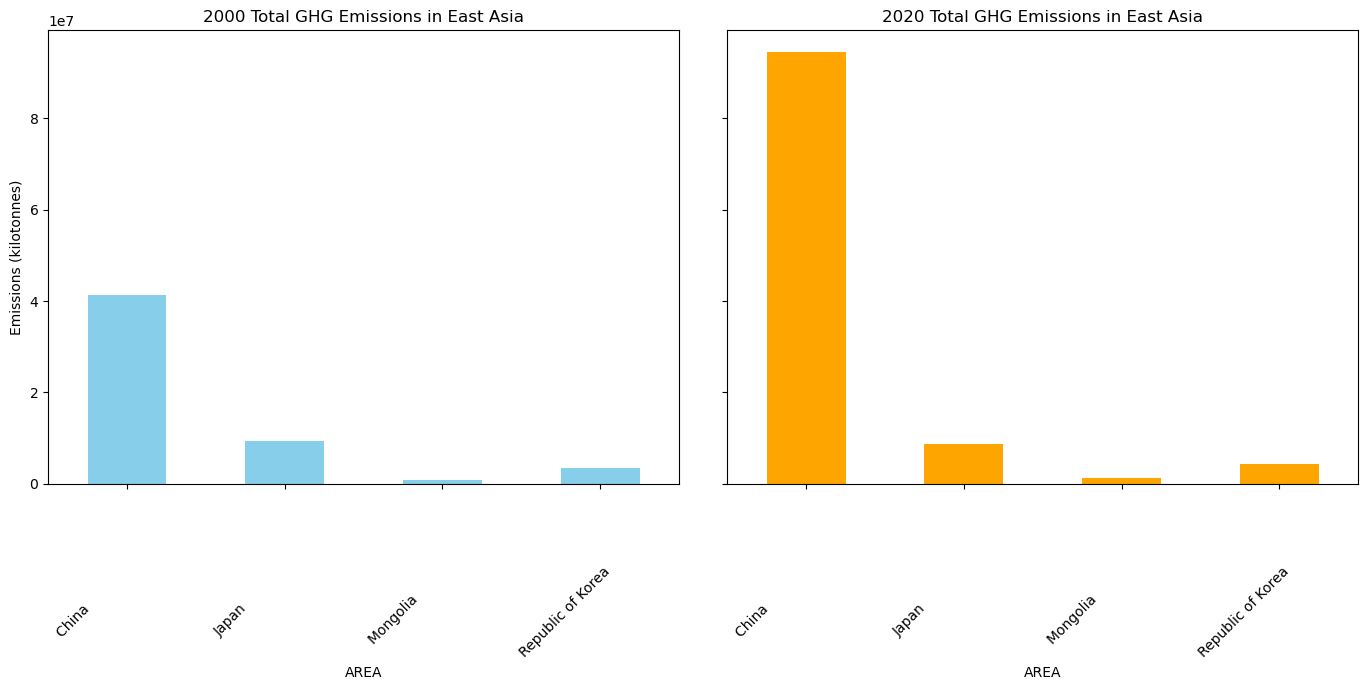

In [2]:
import matplotlib.pyplot as plt

# for all east asia countries
# compare 2000 and 2020 to see long-term trends
emissions_east_asia_2000 = total_emissions.groupby('AREA')['Y2000'].sum()
emissions_east_asia_2020 = total_emissions.groupby('AREA')['Y2020'].sum()

# bar chart to compare the emissions in 2000 and 2020
fig, ax = plt.subplots(1, 2, figsize=(14, 7), sharey=True)  # share y-axis

# data in 2000
emissions_east_asia_2000.plot(kind='bar', color='skyblue', ax=ax[0])
ax[0].set_title('2000 Total GHG Emissions in East Asia')
ax[0].set_ylabel('Emissions (kilotonnes)')
ax[0].tick_params(axis='x', rotation=45)

# data in 2020
emissions_east_asia_2020.plot(kind='bar', color='orange', ax=ax[1])
ax[1].set_title('2020 Total GHG Emissions in East Asia')
ax[1].set_ylabel('Emissions (kilotonnes)')
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Analyzing Food Waste Patterns in China**

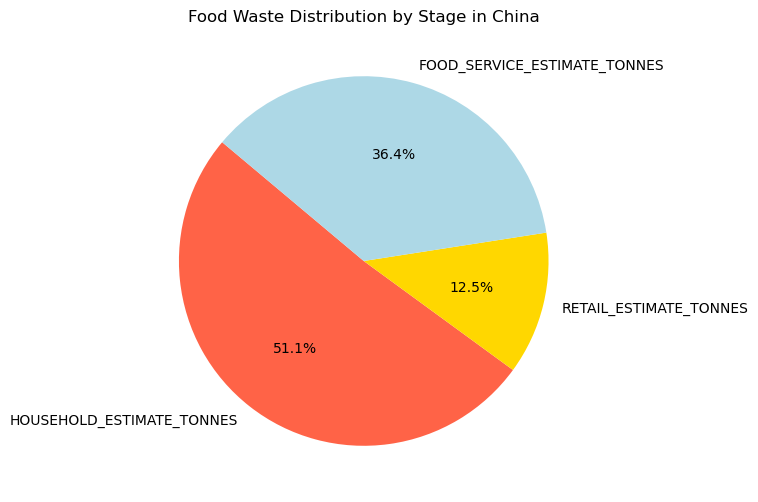

In [3]:
# Aggregating food waste estimates across household, retail and foodservice stages(just consider tonnes/year)
food_waste_china = food_waste.iloc[0]
food_waste_stages = ['HOUSEHOLD_ESTIMATE_TONNES', 'RETAIL_ESTIMATE_TONNES', 'FOOD_SERVICE_ESTIMATE_TONNES']
food_waste_summary = food_waste_china[food_waste_stages]

# pie chart for food waste 
plt.figure(figsize=(8, 6))
food_waste_summary.plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=['tomato', 'gold', 'lightblue'])
plt.title(f'Food Waste Distribution by Stage in China')
plt.ylabel('') 
plt.show()


**Combining agricultural Data with Food Waste Data**

In [4]:
agri_co2_emission.columns

Index(['AREA', 'YEAR', 'SAVANNA_FIRES', 'FOREST_FIRES', 'CROP_RESIDUES',
       'RICE_CULTIVATION', 'DRAINED_ORGANIC_SOILS', 'RESTICIDES_MANUFACTURING',
       'FOOD_TRANSPORT', 'FORESTLAND', 'NET_FOREST_CONVERSION',
       'FOOD_HOUSEHOLD_CONSUMPTION', 'FOOD_RETAIL', 'ON_FARM_ELECTRICITY_USE',
       'FOOD_PACKAGING', 'AGRI_FOOD_SYSTEMS_WASTE_DISPOSAL', 'FOOD_PROCESSING',
       'FERTILIZERS_MANUFACTURING', 'IPPU', 'MANURE_APPLIED_TO_SOILS',
       'MANURE_LEFT_ON_PASTURE', 'MANURE_MANAGEMENT', 'FIRES_IN_ORGANIC_SOILS',
       'FIRES_IN_HUMID_TROPICAL_FORESTS', 'ON_FARM_ENERGY_USE',
       'RURAL_POPULATION', 'URBAN_POPULATION', 'TOTAL_POPULATION_MALE',
       'TOTAL_POPULATION_FEMALE', 'TOTAL_EMISSION', 'AVERAGE_TEMPERATURE'],
      dtype='object')

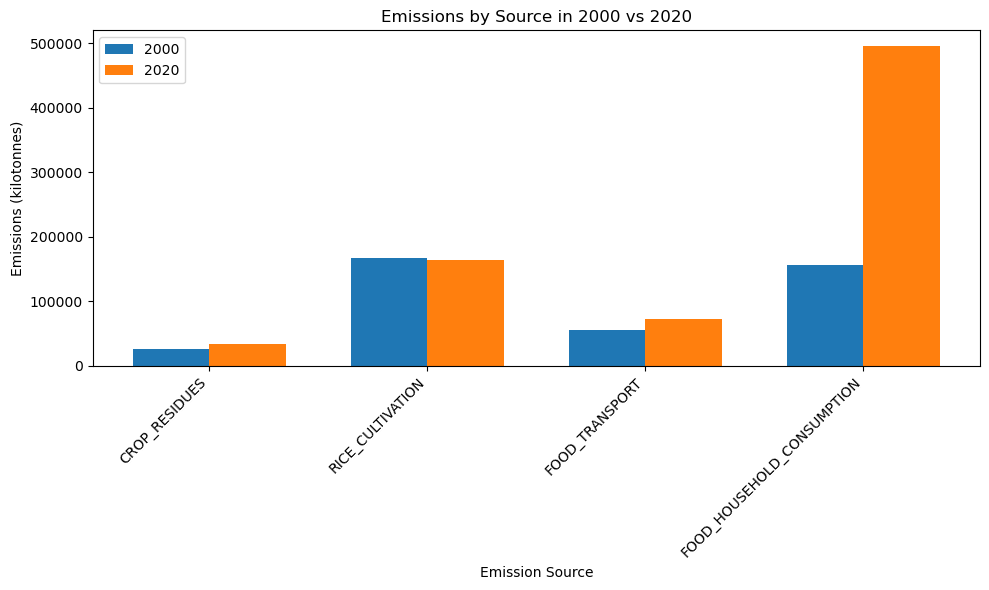

In [5]:
# Pick four household-related agricultural activities
emission_sources = ["CROP_RESIDUES", "RICE_CULTIVATION", "FOOD_TRANSPORT", "FOOD_HOUSEHOLD_CONSUMPTION"]

# Filter data from 2000 and 2020
data_2000_2020 = agri_co2_emission[(agri_co2_emission['YEAR'] == 2000) | (agri_co2_emission['YEAR'] == 2020)]

# Calculate total emissions from a specific emission source in 2000 and 2020
emissions_2000_2020 = data_2000_2020.groupby('YEAR').sum()[["CROP_RESIDUES", "RICE_CULTIVATION", "FOOD_TRANSPORT", "FOOD_HOUSEHOLD_CONSUMPTION"]]

emissions_2000 = emissions_2000_2020.iloc[0]
emissions_2020 = emissions_2000_2020.iloc[1]

fig, ax = plt.subplots(figsize=(10, 6))
index = np.arange(len(emission_sources))
bar_width = 0.35

# bar chart for 2000 and 2020
bars1 = ax.bar(index, emissions_2000, bar_width, label='2000')
bars2 = ax.bar(index + bar_width, emissions_2020, bar_width, label='2020')

ax.set_xlabel('Emission Source')
ax.set_ylabel('Emissions (kilotonnes)')
ax.set_title('Emissions by Source in 2000 vs 2020')
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(emission_sources, rotation=45, ha="right")
ax.legend()

plt.tight_layout()
plt.show()


**Correlation between Emission Source and the Emissions Element**

In [1]:
# Explore the correlation between the four agricultural activities mentioned above and the emissions of different gases
df_combined = pd.concat([co2_emssion_contribute_total_emission, co2_emssion_contribute_total_emission], ignore_index=True)
# code Documentation: https://pandas.pydata.org/docs/reference/api/pandas.crosstab.html to see the how to use the 'crosstab'
cross_tab = pd.crosstab(df_combined['ITEM_TOT'], df_combined['ELEMENT_TOT'])

# heatmap
plt.figure(figsize=(12, 8)) 
sns.heatmap(cross_tab, annot=True, fmt="d", cmap='viridis')
plt.title('Heatmap of ITEM_TOT and ELEMENT_TOT')
plt.xlabel('ELEMENT_TOT')
plt.ylabel('ITEM_TOT')
plt.show()


NameError: name 'pd' is not defined

In [7]:
connection.close()